In [1]:
import pandas as pd

df = pd.read_csv("Data/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [3]:
df.info

<bound method DataFrame.info of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisea

In [4]:
df.describe(include="all")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [6]:
#checking for null values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### No missing values in the dataset

In [7]:
#checking if the values of some parameters is zero or not to check the correctness of data
(df == 0).sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS         704
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak           368
ST_Slope            0
HeartDisease      410
dtype: int64

### Insights
- Although no explicit missing values were found , certain features contained zero values that are medically unrealistic aand were treated as missing data


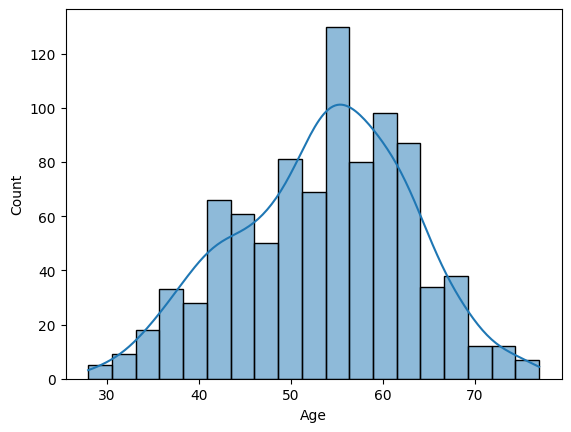

In [8]:
#Univariate Analysis
#checking for the distribution of variable

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Age'], kde=True)
plt.show()

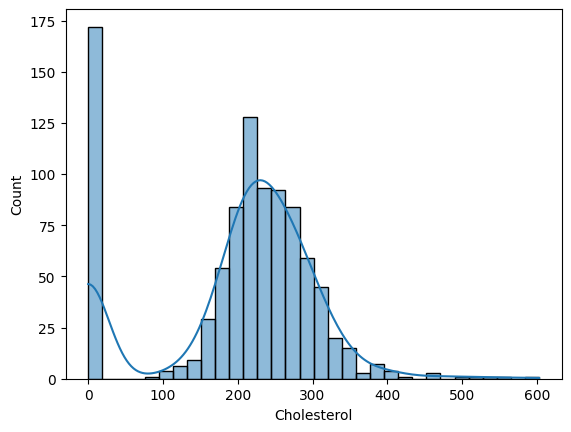

In [9]:
sns.histplot(df['Cholesterol'], kde=True)
plt.show()

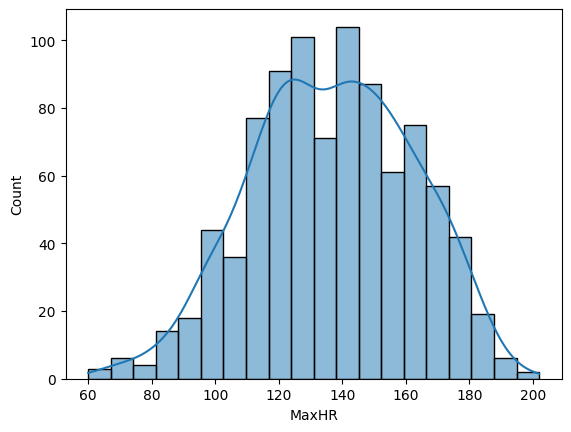

In [10]:
sns.histplot(df['MaxHR'], kde=True)
plt.show()

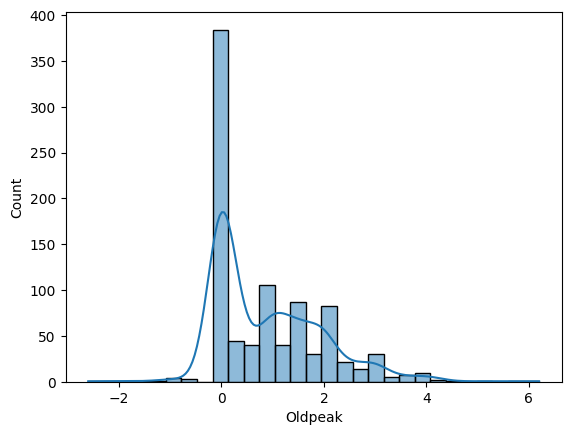

In [11]:
sns.histplot(df['Oldpeak'], kde=True)
plt.show()

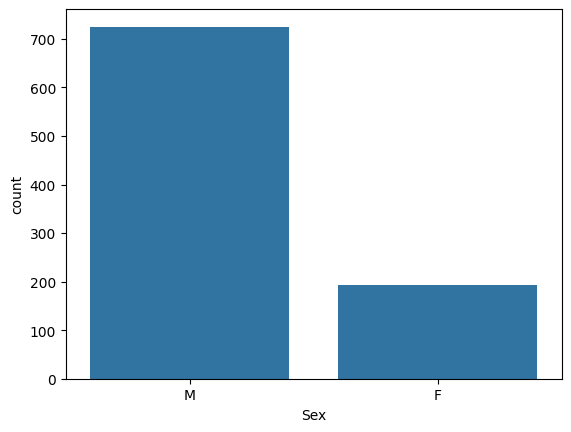

In [12]:
sns.countplot(x='Sex', data=df)
plt.show()

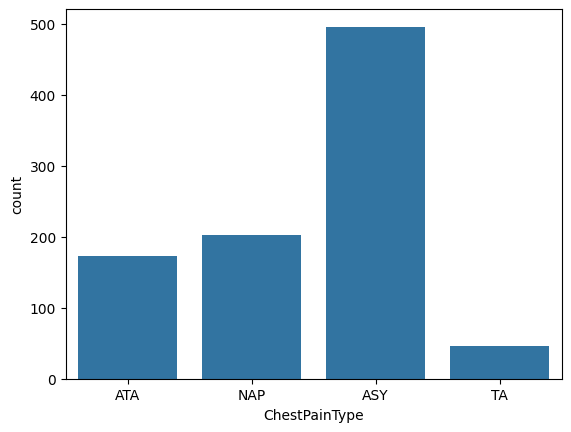

In [13]:
sns.countplot(x='ChestPainType', data=df)
plt.show()

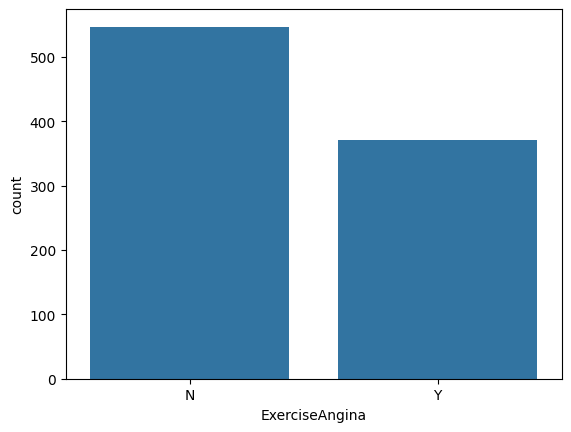

In [14]:
sns.countplot(x='ExerciseAngina', data=df)
plt.show()

## Univariate Analysis
- Majority of patients fall in the 40-60 age range, indicating higher concenntration in middle aged group
- Cholesterol shows high variability, suggesting presence of outliers
- Dataset contains moore male than female patients, indicating slight gender imbalance
- OldPeak is right-skewed, with most values near zero and few extreme values

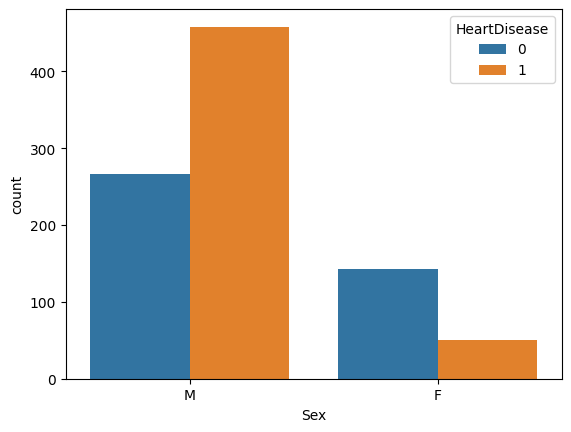

In [15]:
#Bivariate Analysis
#checking for the relationship between target variable and other variables

#sex v/s heart disease
sns.countplot(x='Sex', hue='HeartDisease', data=df)
plt.show()

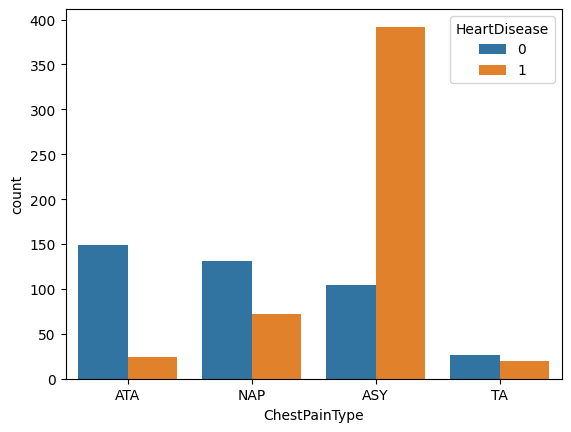

In [16]:
#chest pain type v/s heart disease
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)
plt.show()

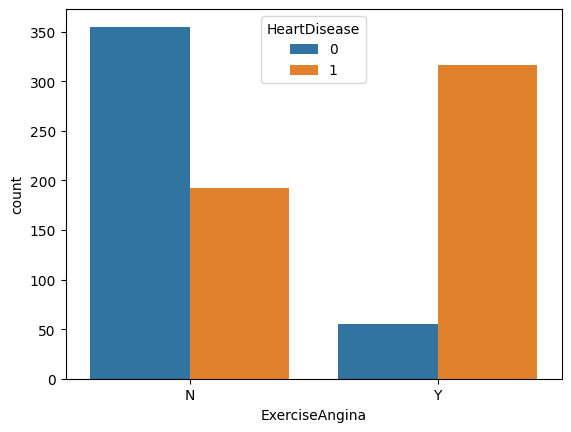

In [17]:
#exercise angina v/s heart disease
sns.countplot(x='ExerciseAngina', hue='HeartDisease', data=df)
plt.show()

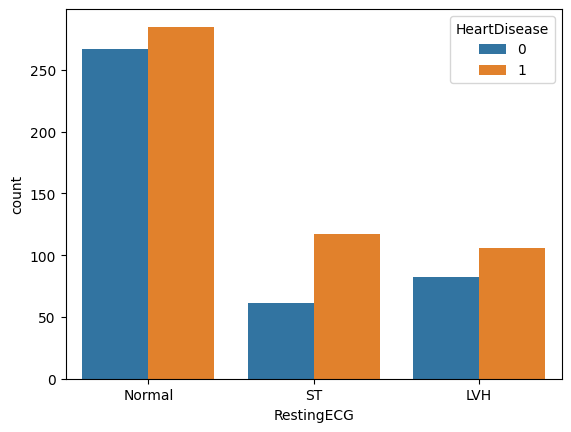

In [18]:
#resting ecg v/s heart disease
sns.countplot(x='RestingECG', hue='HeartDisease', data=df)
plt.show()

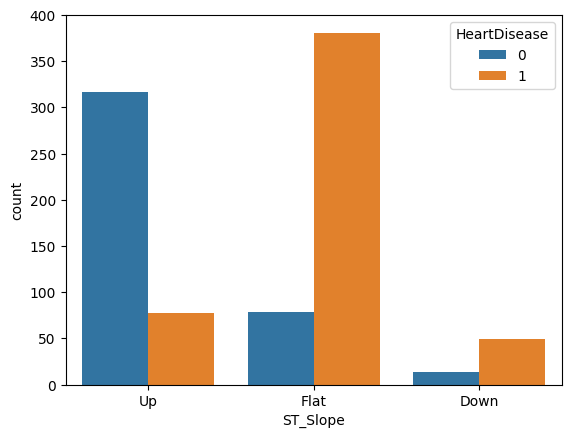

In [19]:
#st slope v/s heart disease
sns.countplot(x='ST_Slope', hue='HeartDisease', data=df)
plt.show()

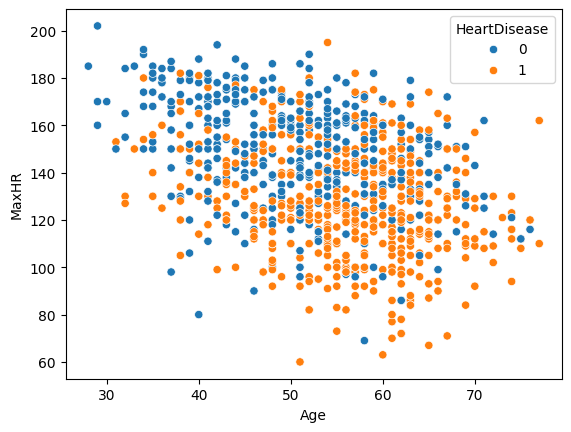

In [20]:
# age v/s max heart rate
sns.scatterplot(x='Age', y='MaxHR', hue='HeartDisease', data=df)
plt.show()

## Insights
- Male patients exibhits a higher prevalence of heart disease compared to females, indicating gender as a significant risk factor.
- Patients with asymptomatic chest pain (ASY) show a significantly higher likelihood of disease.
- The presence of excercise-induced anigma is strongly associated with heart disease.
- Older individials are more likely to suffer from herat disease.
- Patient with heat disease are likely to have higher OldPeak values, showing a strong posituve relation between ST depression and heart disease.
- Maximum Heart Rate (MaxHR) tends to be lower in patients with heart disease.
- Certain ST_slope categories (especially flats) are more associated with heart disease, highlighting its diagnostic importance.
- Features like Resting ECG show weaker or less consistent relationships, suggesting they may be less influential predictors.

##### These observations indicates that features such as age, chest pain type, exercise induces anigma, oldpeak and Max heart rate are significant pridictors of heart disease and should be prioritized during model training.

In [21]:
#Fixing invalid values in the dataset

import numpy as np

df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].mean())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].mean())

### Converting Categorical Variables to Numeric
- Sex : M=0, F=1
- ChestPainType : ATA=0, NAP=1, ASY=2, TA=3
- RestingECG : Normal=0,ST=1,LVH=2
- ExerciseAnigna : N=0, Y=1
- ST_Slope : Up=0, Flat=1, Down=2

In [22]:
df = pd.get_dummies(df, drop_first=True)

In [23]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Feature Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
df.to_csv("../Data/heart_cleaned.csv", index=False)